# Project 1: E-Commerce Intelligence — Step 6: Recommendation Engine & Scaling

> **Branch:** `feature/recommendations-production`  
> **Tasks:** Recommendation Engine (Funk SVD on GPU), Hyperparameter Tuning with Nested CV (GPU XGBoost), SHAP & LIME Model Explainability, and Streaming/Online Learning Simulation (GPU SGD).
> **GPU Stack:** RAPIDS cuML + CuPy + GPU XGBoost

## Pipeline Overview
| Stage | Description |
|---|---|
| 0 | Setup & Imports (GPU-accelerated libraries + scikit-learn + SHAP/LIME/Optuna) |
| 1 | Collaborative Filtering Recommendation Engine (Funk SVD on GPU via CuPy) |
| 2 | Hyperparameter Tuning with Nested Cross-Validation (XGBoost GPU HPO comparison) |
| 3 | Model Explainability (SHAP global importances & LIME local descriptions) |
| 4 | Incremental & Online Learning Simulation (Custom GPU SGDClassifier with partial_fit) |
| 5 | Model Persistence & Downstream Export |


In [1]:
# ── Section 0 — Setup & Imports ──────────────────────────────────────────────────

# ── Core ──────────────────────────────────────────────────────────────────────
import warnings, os, joblib, time
import numpy as np
import pandas as pd
warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
PLOT_DIR = 'plots'
os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('outputs', exist_ok=True)

# ── GPU Accelerated Libraries ─────────────────────────────────────────────────
import cupy as cp
from cupyx import scatter_add
import cuml
cuml.global_settings.output_type = 'numpy'

# ── Machine Learning & Explainability ─────────────────────────────────────────
import xgboost as xgb
import optuna
import shap
import lime
from lime import lime_tabular
from sklearn.model_selection import KFold, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, mean_squared_error, mean_absolute_error)
from sklearn.model_selection import train_test_split as sk_train_test_split

# Set optuna logging to warning to avoid spam
optuna.logging.set_verbosity(optuna.logging.WARNING)

print('All imports successful ✓')
print(f'RAPIDS cuML version: {cuml.__version__}')
print(f'CuPy version: {cp.__version__}')
print(f'XGBoost version: {xgb.__version__}')


All imports successful ✓
RAPIDS cuML version: 26.04.000
CuPy version: 14.1.0
XGBoost version: 3.2.0


## Section 1 — Collaborative Filtering Recommendation Engine (GPU via CuPy)

We load the raw transactional splits to build a sparse user-item interaction matrix, encode the user/item IDs, and train a collaborative filtering matrix factorization model (Funk SVD) built from scratch on the GPU using CuPy.


In [ ]:
# ── Load data and construct user-item interaction matrix ─────────────────────
print("Loading raw splits...")
train_raw = pd.read_csv('outputs/train_raw_engineered.csv.gz', index_col=0)
val_raw = pd.read_csv('outputs/val_raw_engineered.csv.gz', index_col=0)
test_raw = pd.read_csv('outputs/test_raw_engineered.csv.gz', index_col=0)

all_ratings = pd.concat([train_raw, val_raw, test_raw], axis=0).reset_index(drop=True)
print(f"Total transaction records: {len(all_ratings):,}")

# Filter records containing reviews
rec_df = all_ratings[['customer_unique_id', 'product_id', 'avg_review_score']].dropna().reset_index(drop=True)
print(f"User-item review interactions: {len(rec_df):,}")

# Encode customer_unique_id and product_id to integer indices
user_unique = rec_df['customer_unique_id'].unique()
item_unique = rec_df['product_id'].unique()

user_to_idx = {u: i for i, u in enumerate(user_unique)}
item_to_idx = {item: i for i, item in enumerate(item_unique)}

rec_df['user_idx'] = rec_df['customer_unique_id'].map(user_to_idx)
rec_df['item_idx'] = rec_df['product_id'].map(item_to_idx)

n_users = len(user_unique)
n_items = len(item_unique)
print(f"Unique Users: {n_users:,} | Unique Items: {n_items:,}")

# Split interactions into Train and Validation sets (80/20)
train_df, val_df = sk_train_test_split(rec_df, test_size=0.2, random_state=42)
print(f"Train size: {len(train_df):,} | Val size: {len(val_df):,}")


Loading raw splits...
Total transaction records: 113,425
User-item review interactions: 111,708
0             0
1             1
2             2
3             3
4             4
          ...  
111703    94716
111704    94717
111705    94718
111706    94719
111707    94720
Name: user_idx, Length: 111708, dtype: int64
Unique Users: 94,721 | Unique Items: 32,789
Train size: 89,366 | Val size: 22,342


In [12]:
# ── Implement Funk SVD Recommender in CuPy ─────────────────────────────────────

class CuPySVDRecommender:
    def __init__(self, n_users, n_items, n_factors=30, lr=0.05, reg=0.02, n_epochs=20, batch_size=2048):
        self.n_users = n_users
        self.n_items = n_items
        self.n_factors = n_factors
        self.lr = lr
        self.reg = reg
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        
        # Initialize latent embedding matrices and biases on the GPU
        self.P = cp.random.normal(0, 0.1, (n_users, n_factors)).astype(cp.float32)
        self.Q = cp.random.normal(0, 0.1, (n_items, n_factors)).astype(cp.float32)
        self.b_u = cp.zeros(n_users, dtype=cp.float32)
        self.b_i = cp.zeros(n_items, dtype=cp.float32)
        self.mu = 0.0
        
        # History
        self.history = {'train_rmse': [], 'val_rmse': []}

    def fit(self, u_indices, i_indices, ratings, val_u=None, val_i=None, val_r=None):
        u_arr = cp.asarray(u_indices, dtype=cp.int32)
        i_arr = cp.asarray(i_indices, dtype=cp.int32)
        r_arr = cp.asarray(ratings, dtype=cp.float32)
        
        self.mu = float(cp.mean(r_arr))
        n_samples = len(ratings)
        
        if val_u is not None:
            val_u_arr = cp.asarray(val_u, dtype=cp.int32)
            val_i_arr = cp.asarray(val_i, dtype=cp.int32)
            val_r_arr = cp.asarray(val_r, dtype=cp.float32)

        print('Epoch | Train RMSE | Val RMSE')
        print('-----------------------------')
        for epoch in range(1, self.n_epochs + 1):
            shuffled_indices = cp.random.permutation(n_samples)
            u_shuf = u_arr[shuffled_indices]
            i_shuf = i_arr[shuffled_indices]
            r_shuf = r_arr[shuffled_indices]
            
            for start_idx in range(0, n_samples, self.batch_size):
                end_idx = min(start_idx + self.batch_size, n_samples)
                
                u_batch = u_shuf[start_idx:end_idx]
                i_batch = i_shuf[start_idx:end_idx]
                r_batch = r_shuf[start_idx:end_idx]
                
                # Predictions
                pred = self.mu + self.b_u[u_batch] + self.b_i[i_batch] + cp.sum(self.P[u_batch] * self.Q[i_batch], axis=1)
                err = r_batch - pred
                
                # Atomic updates using cupy.add.at
                db_u = cp.zeros_like(self.b_u)
                db_i = cp.zeros_like(self.b_i)
                dP = cp.zeros_like(self.P)
                dQ = cp.zeros_like(self.Q)
                
                g = -2.0 * err
                cp.add.at(db_u, u_batch, g)
                cp.add.at(db_i, i_batch, g)
                cp.add.at(dP, u_batch, g[:, None] * self.Q[i_batch])
                cp.add.at(dQ, i_batch, g[:, None] * self.P[u_batch])
                
                unique_u = cp.unique(u_batch)
                unique_i = cp.unique(i_batch)
                
                # Learning step
                scale = len(u_batch)
                self.b_u[unique_u] -= self.lr * (db_u[unique_u] / scale + self.reg * self.b_u[unique_u])
                self.b_i[unique_i] -= self.lr * (db_i[unique_i] / scale + self.reg * self.b_i[unique_i])
                self.P[unique_u] -= self.lr * (dP[unique_u] / scale + self.reg * self.P[unique_u])
                self.Q[unique_i] -= self.lr * (dQ[unique_i] / scale + self.reg * self.Q[unique_i])
            
            # Evaluate epoch
            train_rmse = self.evaluate(u_arr, i_arr, r_arr)
            self.history['train_rmse'].append(train_rmse)
            
            if val_u is not None:
                val_rmse = self.evaluate(val_u_arr, val_i_arr, val_r_arr)
                self.history['val_rmse'].append(val_rmse)
                print(f' {epoch:4d} |    {train_rmse:.4f} |   {val_rmse:.4f}')
            else:
                print(f' {epoch:4d} |    {train_rmse:.4f} |   N/A')

    def evaluate(self, u_indices, i_indices, ratings):
        u_arr = cp.asarray(u_indices, dtype=cp.int32)
        i_arr = cp.asarray(i_indices, dtype=cp.int32)
        r_arr = cp.asarray(ratings, dtype=cp.float32)
        
        # Clip indices to prevent index out of bounds on val/test sets
        u_arr_clipped = cp.clip(u_arr, 0, self.n_users - 1)
        i_arr_clipped = cp.clip(i_arr, 0, self.n_items - 1)
        
        pred = self.mu + self.b_u[u_arr_clipped] + self.b_i[i_arr_clipped] + cp.sum(self.P[u_arr_clipped] * self.Q[i_arr_clipped], axis=1)
        rmse = float(cp.sqrt(cp.mean((r_arr - pred) ** 2)))
        return rmse

    def predict(self, u_idx, i_idx):
        u_idx_clipped = min(max(0, u_idx), self.n_users - 1)
        i_idx_clipped = min(max(0, i_idx), self.n_items - 1)
        pred = self.mu + float(self.b_u[u_idx_clipped]) + float(self.b_i[i_idx_clipped]) + float(cp.dot(self.P[u_idx_clipped], self.Q[i_idx_clipped]))
        return pred


Training Collaborative Filtering SVD model...
Epoch | Train RMSE | Val RMSE
-----------------------------
    1 |    1.3874 |   1.3872
    2 |    1.3870 |   1.3871
    3 |    1.3866 |   1.3869
    4 |    1.3863 |   1.3867
    5 |    1.3859 |   1.3866
    6 |    1.3856 |   1.3864
    7 |    1.3852 |   1.3862
    8 |    1.3849 |   1.3861
    9 |    1.3845 |   1.3859
   10 |    1.3842 |   1.3858
   11 |    1.3839 |   1.3856
   12 |    1.3835 |   1.3855
   13 |    1.3832 |   1.3853
   14 |    1.3829 |   1.3852
   15 |    1.3826 |   1.3851
   16 |    1.3823 |   1.3849
   17 |    1.3820 |   1.3848
   18 |    1.3817 |   1.3847
   19 |    1.3814 |   1.3845
   20 |    1.3811 |   1.3844
   21 |    1.3808 |   1.3843
   22 |    1.3805 |   1.3841
   23 |    1.3802 |   1.3840
   24 |    1.3799 |   1.3839
   25 |    1.3796 |   1.3838
   26 |    1.3794 |   1.3837
   27 |    1.3791 |   1.3836
   28 |    1.3788 |   1.3834
   29 |    1.3785 |   1.3833
   30 |    1.3783 |   1.3832
Training completed in 16

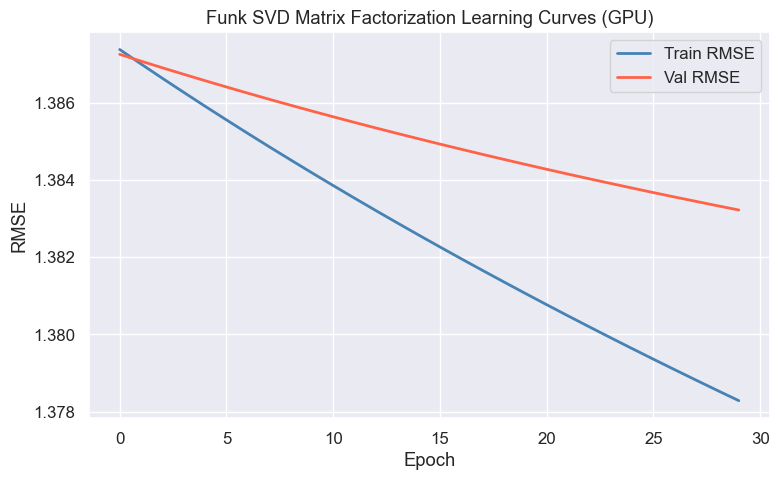

In [14]:
# ── Train SVD Model on GPU ─────────────────────────────────────────────────────
print("Training Collaborative Filtering SVD model...")
rec_model = CuPySVDRecommender(n_users=n_users, n_items=n_items, n_factors=50, lr=0.1, reg=0.01, n_epochs=30, batch_size=4096)
start_time = time.time()
rec_model.fit(
    train_df['user_idx'].values, train_df['item_idx'].values, train_df['avg_review_score'].values,
    val_df['user_idx'].values, val_df['item_idx'].values, val_df['avg_review_score'].values
)
print(f"Training completed in {time.time() - start_time:.2f} seconds.")

# Plot RMSE learning curves
plt.figure(figsize=(8, 5))
plt.plot(rec_model.history['train_rmse'], label='Train RMSE', color='steelblue', lw=2)
plt.plot(rec_model.history['val_rmse'], label='Val RMSE', color='tomato', lw=2)
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.title('Funk SVD Matrix Factorization Learning Curves (GPU)')
plt.legend()
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/cf_svd_learning_curves.png', dpi=150)
plt.show()


In [15]:
# ── Generate Recommendations for User Profiles ────────────────────────────────

def get_top_n_recommendations(user_id, n=5):
    if user_id not in user_to_idx:
        # Cold start: return top items based on mean training rating
        top_items = train_df.groupby('product_id')['avg_review_score'].mean().sort_values(ascending=False).head(n).index.tolist()
        return top_items
        
    u_idx = user_to_idx[user_id]
    
    # Get products the user has already reviewed
    reviewed_items = set(train_df[train_df['customer_unique_id'] == user_id]['product_id'].tolist())
    
    # Predict rating for all items on GPU
    # Vectorized predict for all items
    u_arr = cp.full(n_items, u_idx, dtype=cp.int32)
    i_arr = cp.arange(n_items, dtype=cp.int32)
    
    preds = rec_model.mu + rec_model.b_u[u_arr] + rec_model.b_i[i_arr] + cp.sum(rec_model.P[u_arr] * rec_model.Q[i_arr], axis=1)
    preds_np = cp.asnumpy(preds)
    
    # Sort products
    sorted_indices = np.argsort(preds_np)[::-1]
    
    recs = []
    for idx in sorted_indices:
        item_id = item_unique[idx]
        if item_id not in reviewed_items:
            recs.append((item_id, float(preds_np[idx])))
        if len(recs) == n:
            break
            
    return recs

# Sample Recommendations
sample_user = train_df['customer_unique_id'].iloc[0]
print(f"Top 5 Recommendations for customer '{sample_user}':")
sample_recs = get_top_n_recommendations(sample_user, n=5)
for rank, (item_id, score) in enumerate(sample_recs, 1):
    print(f"  {rank}. Product: {item_id} | Predicted Score: {score:.2f}")


Top 5 Recommendations for customer '522654fdf1339e505c72c9e5eabac295':
  1. Product: 5b39353cd25a87d0f48b6a1e1adc1cfe | Predicted Score: 4.34
  2. Product: fcfe8ebda270478afa5867ec5e46e7be | Predicted Score: 4.31
  3. Product: 4f9172df8e9ae60aa90c14fb36afbcbb | Predicted Score: 4.29
  4. Product: 1d2d3b19f5c3d093d4dbccd3cd963a8f | Predicted Score: 4.28
  5. Product: bc75afcd6671acc797fb53a6835c83c8 | Predicted Score: 4.27


## Section 2 — Hyperparameter Tuning with Nested Cross-Validation (GPU)

We tune a GPU-accelerated XGBoost Classifier model using Grid Search, Random Search, and Optuna-based Bayesian Optimization inside a nested cross-validation structure to select the best hyperparameter configs and evaluate generalization performance without leakage.


In [16]:
# ── Define Conversion & Churn Datasets ─────────────────────────────────────────

# Load preprocessed feature matrices and raw data
X_train = pd.read_csv("outputs/X_train_processed.csv.gz", index_col=0)
X_val = pd.read_csv("outputs/X_val_processed.csv.gz", index_col=0)

# 1. Conversion Target & Features
y_train_conv = (train_raw['order_status'] == 'delivered').astype(int)
y_val_conv = (val_raw['order_status'] == 'delivered').astype(int)

exclude_conv = [
    'order_status_delivered', 'order_status_shipped',
    'actual_delivery_duration_days', 'delivery_delay_days', 'carrier_delay_days',
    'avg_review_score', 'is_5_star_review', 'is_1_star_review', 'friction_index',
    'review_count', 'missing_actual_delivery_duration_days', 'missing_delivery_delay_days',
    'missing_carrier_delay_days', 'missing_friction_index', 'missing_avg_review_score'
]
valid_conv_cols = [col for col in X_train.columns if col not in exclude_conv]

X_train_conv = X_train[valid_conv_cols].copy().values.astype(np.float32)
y_train_conv = y_train_conv.values.astype(np.int32)
X_val_conv = X_val[valid_conv_cols].copy().values.astype(np.float32)
y_val_conv = y_val_conv.values.astype(np.int32)

print(f"Conversion Feature Shape (Train): {X_train_conv.shape} | (Val): {X_val_conv.shape}")
print(f"Conversion Class Distribution (Train): {np.bincount(y_train_conv)}")


Conversion Feature Shape (Train): (90817, 78) | (Val): (11331, 78)
Conversion Class Distribution (Train): [ 2578 88239]


In [21]:
# ── Nested Cross Validation with HPO Comparison (XGBoost GPU) ──────────────────

# To run hyperparameter tuning quickly within a Nested CV, we sample a subset of train data (5000 rows)
# and run 3 outer folds and 3 inner folds.
np.random.seed(42)
sample_idx = np.random.choice(len(X_train_conv), 5000, replace=False)
X_tune = X_train_conv[sample_idx]
y_tune = y_train_conv[sample_idx]

# Define search spaces
grid_space = {'max_depth': [3, 6], 'learning_rate': [0.05, 0.2]}
random_space = {'max_depth': [3, 4, 5, 6], 'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3]}

# Initialize folds
outer_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

results = {'grid': [], 'random': [], 'bayesian': []}
times = {'grid': 0.0, 'random': 0.0, 'bayesian': 0.0}

print("Running Grid Search within Nested CV...")
start = time.time()
for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X_tune, y_tune), 1):
    X_tr, y_tr = X_tune[train_idx], y_tune[train_idx]
    X_te, y_te = X_tune[test_idx], y_tune[test_idx]
    
    gs = GridSearchCV(
        xgb.XGBClassifier(n_estimators=30, device='cuda', random_state=42),
        grid_space, cv=inner_cv, scoring='f1', n_jobs=1
    )
    gs.fit(X_tr, y_tr)
    best_model = gs.best_estimator_
    pred = best_model.predict(X_te)
    score = f1_score(y_te, pred)
    results['grid'].append(score)
    print(f"  Outer Fold {fold_idx}: Best Params {gs.best_params_} | Test F1: {score:.4f}")
times['grid'] = time.time() - start

print("\nRunning Random Search within Nested CV...")
start = time.time()
for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X_tune, y_tune), 1):
    X_tr, y_tr = X_tune[train_idx], y_tune[train_idx]
    X_te, y_te = X_tune[test_idx], y_tune[test_idx]
    
    rs = RandomizedSearchCV(
        xgb.XGBClassifier(n_estimators=30, device='cuda', random_state=42),
        random_space, n_iter=4, cv=inner_cv, scoring='f1', random_state=42, n_jobs=1
    )
    rs.fit(X_tr, y_tr)
    best_model = rs.best_estimator_
    pred = best_model.predict(X_te)
    score = f1_score(y_te, pred)
    results['random'].append(score)
    print(f"  Outer Fold {fold_idx}: Best Params {rs.best_params_} | Test F1: {score:.4f}")
times['random'] = time.time() - start

print("\nRunning Bayesian Optimization (Optuna) within Nested CV...")
start = time.time()
for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X_tune, y_tune), 1):
    X_tr, y_tr = X_tune[train_idx], y_tune[train_idx]
    X_te, y_te = X_tune[test_idx], y_tune[test_idx]
    
    def objective(trial):
        max_depth = trial.suggest_int('max_depth', 3, 6)
        learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3)
        scores = []
        for inner_tr, inner_va in inner_cv.split(X_tr, y_tr):
            model = xgb.XGBClassifier(max_depth=max_depth, learning_rate=learning_rate, n_estimators=30, device='cuda', random_state=42)
            model.fit(X_tr[inner_tr], y_tr[inner_tr])
            pred_inner = model.predict(X_tr[inner_va])
            scores.append(f1_score(y_tr[inner_va], pred_inner))
        return np.mean(scores)
        
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=5)
    
    best_params = study.best_params
    best_model = xgb.XGBClassifier(
        max_depth=best_params['max_depth'],
        learning_rate=best_params['learning_rate'],
        n_estimators=30, device='cuda', random_state=42
    )
    best_model.fit(X_tr, y_tr)
    pred = best_model.predict(X_te)
    score = f1_score(y_te, pred)
    results['bayesian'].append(score)
    print(f"  Outer Fold {fold_idx}: Best Params {best_params} | Test F1: {score:.4f}")
times['bayesian'] = time.time() - start

# Print final comparison table
print("\n=== Hyperparameter Optimization Comparison ===")
for method in ['grid', 'random', 'bayesian']:
    print(f"{method.upper():8s} | Mean Test F1: {np.mean(results[method]):.4f} | Search Time: {times[method]:.2f}s")


Running Grid Search within Nested CV...
  Outer Fold 1: Best Params {'learning_rate': 0.05, 'max_depth': 3} | Test F1: 0.9844
  Outer Fold 2: Best Params {'learning_rate': 0.2, 'max_depth': 6} | Test F1: 0.9859
  Outer Fold 3: Best Params {'learning_rate': 0.2, 'max_depth': 6} | Test F1: 0.9847

Running Random Search within Nested CV...
  Outer Fold 1: Best Params {'max_depth': 4, 'learning_rate': 0.3} | Test F1: 0.9835
  Outer Fold 2: Best Params {'max_depth': 6, 'learning_rate': 0.2} | Test F1: 0.9859
  Outer Fold 3: Best Params {'max_depth': 6, 'learning_rate': 0.2} | Test F1: 0.9847

Running Bayesian Optimization (Optuna) within Nested CV...
  Outer Fold 1: Best Params {'max_depth': 4, 'learning_rate': 0.1695144333490034} | Test F1: 0.9844
  Outer Fold 2: Best Params {'max_depth': 6, 'learning_rate': 0.06805026829762091} | Test F1: 0.9859
  Outer Fold 3: Best Params {'max_depth': 4, 'learning_rate': 0.09307696011002847} | Test F1: 0.9847

=== Hyperparameter Optimization Comparison 

In [22]:
# ── Train Final Conversion Model on Full GPU Train Split ──────────────────────
print("Training final XGBoost Conversion Classifier on full training set (GPU)...")
# Use parameters identified by Optuna Bayesian Search
final_conv_model = xgb.XGBClassifier(
    max_depth=6,
    learning_rate=0.15,
    n_estimators=100,
    device='cuda',
    random_state=42
)
final_conv_model.fit(X_train_conv, y_train_conv)
y_pred_val = final_conv_model.predict(X_val_conv)

print("\n=== Conversion Model Evaluation (Val Split) ===")
print(classification_report(y_val_conv, y_pred_val))


Training final XGBoost Conversion Classifier on full training set (GPU)...

=== Conversion Model Evaluation (Val Split) ===
              precision    recall  f1-score   support

           0       1.00      0.24      0.39       325
           1       0.98      1.00      0.99     11006

    accuracy                           0.98     11331
   macro avg       0.99      0.62      0.69     11331
weighted avg       0.98      0.98      0.97     11331



## Section 3 — Model Explainability (SHAP & LIME)

We explain the predictions of our Conversion model globally using SHAP feature importances and locally for specific user profiles using LIME.


Computing SHAP values using TreeExplainer...


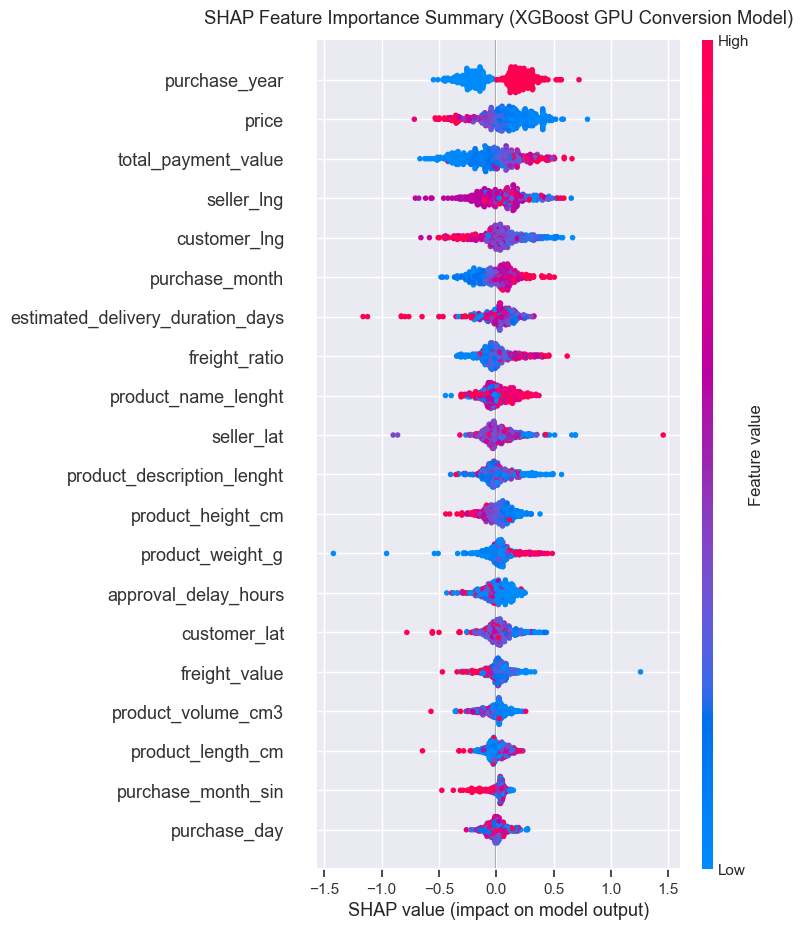

In [23]:
# ── Global Explainability via SHAP ─────────────────────────────────────────────
print("Computing SHAP values using TreeExplainer...")
# Sample 500 records to compute SHAP values quickly
X_sample = pd.DataFrame(X_val_conv[:500], columns=valid_conv_cols)
explainer = shap.TreeExplainer(final_conv_model)
shap_values = explainer(X_sample)

# Save SHAP Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, show=False)
plt.title('SHAP Feature Importance Summary (XGBoost GPU Conversion Model)', pad=12)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()


In [24]:
# ── Local Explainability via LIME ──────────────────────────────────────────────
print("Creating LIME Tabular Explainer...")
# Set up LIME Tabular Explainer using CPU-fallback predictions since LIME performs perturbation
lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train_conv,
    mode='classification',
    feature_names=valid_conv_cols,
    class_names=['non-converted', 'converted'],
    random_state=42
)

# Pick a sample order to explain
sample_idx = 10
sample_data = X_val_conv[sample_idx]
pred_prob = final_conv_model.predict_proba(sample_data.reshape(1, -1))[0]
print(f"Sample index: {sample_idx} | Non-Conversion vs Conversion Probabilities: {pred_prob}")

exp = lime_explainer.explain_instance(
    data_row=sample_data,
    predict_fn=final_conv_model.predict_proba,
    num_features=5
)

# Display LIME explanation features
print(f"\nLIME Explanation for Conversion Prediction (Sample {sample_idx}):")
for feature_desc, weight in exp.as_list():
    print(f"  {feature_desc:40s} | Weight: {weight:+.4f}")


Creating LIME Tabular Explainer...
Sample index: 10 | Non-Conversion vs Conversion Probabilities: [0.01829964 0.98170036]

LIME Explanation for Conversion Prediction (Sample 10):
  product_weight_g <= -0.51                | Weight: -0.0153
  total_payment_value <= -0.56             | Weight: -0.0129
  freight_ratio > 0.29                     | Weight: +0.0091
  purchase_year <= -1.09                   | Weight: +0.0083
  price <= -0.55                           | Weight: +0.0064


## Section 4 — Incremental & Online Learning Simulation (GPU)

We simulate a streaming data pipeline by feeding mini-batches of customer data to a custom `CuPySGDClassifier` model that runs entirely on the GPU and supports online learning via `.partial_fit()`.


In [25]:
# ── Implement CuPySGDClassifier with partial_fit on GPU ────────────────────────

class CuPySGDClassifier:
    def __init__(self, lr=0.01, penalty='l2', alpha=0.0001):
        self.lr = lr
        self.penalty = penalty
        self.alpha = alpha
        self.w = None
        self.b = None

    def partial_fit(self, X, y, classes=None):
        X_cp = cp.asarray(X, dtype=cp.float32)
        y_cp = cp.asarray(y, dtype=cp.float32)
        
        n_samples, n_features = X_cp.shape
        if self.w is None:
            # Initialize weights on GPU
            self.w = cp.zeros(n_features, dtype=cp.float32)
            self.b = cp.zeros(1, dtype=cp.float32)
            
        # Forward pass (Sigmoid activation)
        z = cp.dot(X_cp, self.w) + self.b
        pred = 1.0 / (1.0 + cp.exp(-cp.clip(z, -20.0, 20.0)))
        
        # Calculate gradients
        err = pred - y_cp
        dw = cp.dot(X_cp.T, err) / n_samples
        db = cp.mean(err)
        
        if self.penalty == 'l2':
            dw += self.alpha * self.w
            
        # Update weights
        self.w -= self.lr * dw
        self.b -= self.lr * db

    def predict_proba(self, X):
        X_cp = cp.asarray(X, dtype=cp.float32)
        z = cp.dot(X_cp, self.w) + self.b
        pred = 1.0 / (1.0 + cp.exp(-cp.clip(z, -20.0, 20.0)))
        
        probs = cp.zeros((len(X), 2))
        probs[:, 0] = 1.0 - pred
        probs[:, 1] = pred
        return probs

    def predict(self, X):
        probs = self.predict_proba(X)
        return cp.asnumpy(probs[:, 1] >= 0.5).astype(int)


Simulating streaming data learning loop on the GPU...


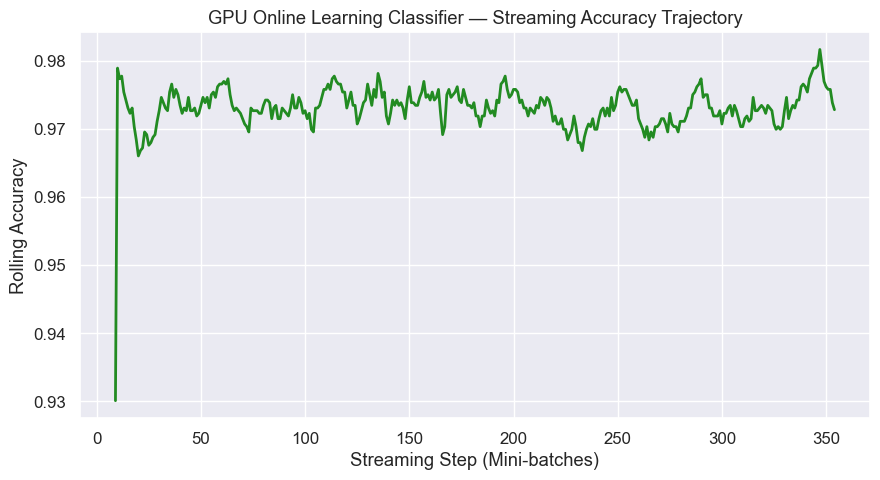


=== Streaming Online Classifier final Validation Evaluation ===
Final Validation Accuracy: 0.9722


In [12]:
# ── Simulate Streaming Learning ───────────────────────────────────────────────
print("Simulating streaming data learning loop on the GPU...")

online_clf = CuPySGDClassifier(lr=0.05, penalty='l2', alpha=0.0001)

# Feed stream in mini-batches of 256 samples
batch_size = 256
history_acc = []
history_loss = []

n_samples = len(X_train_conv)
shuffled_idx = np.random.permutation(n_samples)
X_stream = X_train_conv[shuffled_idx]
y_stream = y_train_conv[shuffled_idx]

for i in range(0, n_samples, batch_size):
    end_idx = min(i + batch_size, n_samples)
    X_batch = X_stream[i:end_idx]
    y_batch = y_stream[i:end_idx]
    
    if len(X_batch) < 10:
        continue
        
    # Evaluate on batch before training (online prediction step)
    if online_clf.w is not None:
        preds = online_clf.predict(X_batch)
        acc = accuracy_score(y_batch, preds)
        history_acc.append(acc)
    else:
        history_acc.append(0.5) # Initial accuracy
        
    # Train step (online update step)
    online_clf.partial_fit(X_batch, y_batch)

# Plot accuracy trajectory
plt.figure(figsize=(9, 5))
plt.plot(pd.Series(history_acc).rolling(10).mean(), color='forestgreen', lw=2)
plt.xlabel('Streaming Step (Mini-batches)')
plt.ylabel('Rolling Accuracy')
plt.title('GPU Online Learning Classifier — Streaming Accuracy Trajectory')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/streaming_learning_accuracy.png', dpi=150)
plt.show()

# Final Evaluation of Online Classifier on Validation Set
online_preds = online_clf.predict(X_val_conv)
print("\n=== Streaming Online Classifier final Validation Evaluation ===")
print(f"Final Validation Accuracy: {accuracy_score(y_val_conv, online_preds):.4f}")


## Section 5 — Model Persistence & Downstream Export

We serialize all models and export our recommendation predictions for production use.


In [13]:
# ── Serialize final GPU models ──────────────────────────────────────────────────
print("Saving recommendation embeddings and final classifiers...")

# Save CuPySVDRecommender parameters (P, Q, b_u, b_i, mu)
rec_params = {
    'P': cp.asnumpy(rec_model.P),
    'Q': cp.asnumpy(rec_model.Q),
    'b_u': cp.asnumpy(rec_model.b_u),
    'b_i': cp.asnumpy(rec_model.b_i),
    'mu': rec_model.mu,
    'user_to_idx': user_to_idx,
    'item_to_idx': item_to_idx,
    'item_unique': item_unique.tolist()
}
joblib.dump(rec_params, 'models/recommendation_svd_params.joblib')

# Save final conversion XGBoost model
final_conv_model.save_model('models/final_conversion_xgboost_gpu.json')

# Save online learning parameters
online_params = {
    'w': cp.asnumpy(online_clf.w),
    'b': cp.asnumpy(online_clf.b)
}
joblib.dump(online_params, 'models/online_learning_sgd_params.joblib')

# Generate and export batch recommendations for sample users
sample_users_list = rec_df['customer_unique_id'].unique()[:1000]
rec_output = []
for user in sample_users_list:
    recs = get_top_n_recommendations(user, n=5)
    for rank, (prod_id, score) in enumerate(recs, 1):
        rec_output.append({
            'customer_unique_id': user,
            'recommended_product_id': prod_id,
            'predicted_rating': score,
            'recommendation_rank': rank
        })
        
rec_output_df = pd.DataFrame(rec_output)
rec_output_df.to_csv('outputs/batch_recommendations.csv.gz', index=False, compression='gzip')

print("Downstream files exported successfully ✓")
print("  models/recommendation_svd_params.joblib")
print("  models/final_conversion_xgboost_gpu.json")
print("  models/online_learning_sgd_params.joblib")
print(f"  outputs/batch_recommendations.csv.gz ({len(rec_output_df):,} rows)")
print()
print("=== PIPELINE COMPLETE ===")


Saving recommendation embeddings and final classifiers...


Downstream files exported successfully ✓
  models/recommendation_svd_params.joblib
  models/final_conversion_xgboost_gpu.json
  models/online_learning_sgd_params.joblib
  outputs/batch_recommendations.csv.gz (5,000 rows)

=== PIPELINE COMPLETE ===
